# 07 — Typed-head router: distilling the structural LLM into a tiny student

The structural-router notebook (ewm-state-machine notebook 21) replaced Jev/Laya with a prompted local LLM
(`StructuralLlmRouter`) that reads the lattice + ring state and returns
a typed decision. This notebook distills that teacher into a **typed
head** — a tiny MLP over a fixed-size feature vector — the same idea as
Laya (non-autoregressive encoder + decision head), but trained on our
own structural state.

The run is a **two-stage diagnosis**, because the prompted teacher turns
out to be heavily biased (almost always `llm_c`):

1. collect teacher soft labels from a closed loop with
   `structural=True`,
2. train a **structural-only** head (`bss` + `drn` + `ring` + phase) —
   and watch it collapse to the teacher's majority class,
3. add a **query one-hot** (still no free text) and watch the head
   recover the teacher's routing,
4. plug the recovered student back into the loop behind the same
   `DecisionRouter` seam and A/B it against the teacher and Jev-mock.

The lesson is the deliverable: the distillation pipeline is correct,
but a degenerate teacher makes the structural-only student a prior —
text (here, the query identity) is what actually drives this teacher.

In [1]:
import os, sys, json

# Same GPU pin as notebook 21: with PCI_BUS_ID on this machine the
# Quadro M1200 is device 0 and the RTX 3060 is device 1.
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

import numpy as np
import torch
import torch.nn as nn

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
sys.path.insert(0, EWM_SM)

from trainer import (
    DecisionRecord,
    DecisionRouter,
    EwmScene,
    JevAdapter,
    LlmAdapter,
    StructuralLlmRouter,
    run_open_loop,
    run_jev_loop,
)

WORK = "/home/alexmy/.cache/ewm-typed-head"
os.makedirs(WORK, exist_ok=True)
ewm = EwmScene()
print("torch sees:", torch.cuda.get_device_name(0),
      round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
print("work:", WORK)

torch sees: NVIDIA GeForce RTX 3060 12.5 GB
work: /home/alexmy/.cache/ewm-typed-head


In [2]:
QUERIES = [
    "What is the capital of France?",                                    # trivial
    "Explain the intuition behind general relativity in three sentences.",  # reasoned
    "Write a haiku about rain.",                                          # creative
    "What is 17 * 24?",                                                   # trivial
    "Compare supervised and unsupervised learning briefly.",              # reasoned
    "What is the speed of light?",                                        # trivial
    "Define entropy in simple words.",                                    # short factual
    "Summarize the plot of Romeo and Juliet.",                            # short factual
]
QUERY_INDEX = {q: i for i, q in enumerate(QUERIES)}

adapter = LlmAdapter(max_new_tokens=32)
teacher = StructuralLlmRouter(max_new_tokens=96)   # the prompted router = teacher
jev     = JevAdapter(mock=True)

print("adapter names:", adapter.names)
print("teacher mode:", "mock" if teacher.mock else "real", "|", teacher.model_id)
print("Jev mode:", "mock" if jev.mock else "real SDK")

adapter names: ('llm_a', 'llm_b', 'llm_c')
teacher mode: real | Qwen/Qwen2.5-1.5B-Instruct
Jev mode: mock


## §1 — Collect teacher soft labels (the distillation dataset)

In [3]:
open_result = run_open_loop(adapter, ewm, QUERIES, WORK, cycles=2, max_new_tokens=32)
print("IICA:", open_result.same_union, "| BSS:", open_result.M_ol.shape,
      "| period:", open_result.period, "(true 8)")

IICA: False | BSS: (16, 3) | period: 8.0 (true 8)


In [4]:
# Teacher closed loop = data collection. structural=True so every
# routing_log entry carries the full lattice + ring state.
teacher_result = run_jev_loop(
    adapter, teacher, ewm, open_result, QUERIES, WORK, T=24, max_new_tokens=32,
    structural=True, ingest_decision=True,
)

data = teacher_result.routing_log
print()
print("teacher decision distribution:")
for n in adapter.names:
    print(f"  {n:6s} {sum(1 for r in data if r['decision']['decision'] == n):2d} steps")
print("mean teacher confidence:",
      round(float(np.mean([r['decision']['confidence'] for r in data])), 4))

with open(f"{WORK}/distill_dataset.jsonl", "w") as fh:
    for r in data:
        fh.write(json.dumps(r) + "\n")
print("saved:", f"{WORK}/distill_dataset.jsonl", f"({len(data)} labelled states)")

t= 0 q=0  route=llm_c   confidence=1.000  gated=False  mock=False


t= 4 q=4  route=llm_b   confidence=0.900  gated=False  mock=False


t= 8 q=0  route=llm_b   confidence=0.900  gated=False  mock=False


t=12 q=4  route=llm_b   confidence=0.900  gated=False  mock=False


t=16 q=0  route=llm_b   confidence=0.900  gated=False  mock=False


t=20 q=4  route=llm_b   confidence=0.900  gated=False  mock=False


t=23 q=7  route=llm_b   confidence=0.000  gated=False  mock=False

teacher decision distribution:
  llm_a   0 steps
  llm_b  17 steps
  llm_c   7 steps
mean teacher confidence: 0.6917
saved: /home/alexmy/.cache/ewm-typed-head/distill_dataset.jsonl (24 labelled states)


## §2 — The typed-head student: structural-only vs + query identity

In [5]:
OPTION_ORDER = sorted(adapter.names)

def structural_features(state):
    """bss (3) + drn (5) + ring (5) + phase (2) + step/16 (1) + bias (1) = 17."""
    bss  = state.get("bss") or {}
    drn  = state.get("drn") or {}
    ring = state.get("ring") or {}
    t = float(state.get("step", 0))
    ph = 2.0 * np.pi * t / 8.0
    feats = [float(bss.get(n, 0.0)) for n in OPTION_ORDER]
    feats += [float(drn.get("dp", 0)), float(drn.get("rp", 0)),
              float(drn.get("np", 0)), float(drn.get("ind1", 0)),
              float(drn.get("ind3", 0))]
    feats += [float(ring.get("residual", 0)), float(ring.get("in_span", False)),
              float(ring.get("dim", 0)), float(ring.get("rotation_count", 0)),
              float(ring.get("spill_first", 0))]
    feats += [np.sin(ph), np.cos(ph), t / 16.0, 1.0]
    return np.asarray(feats, dtype=np.float32)

def query_features(state):
    """One-hot of the query index (8) — identity, not free text."""
    q = str(state.get("query", ""))
    onehot = np.zeros(len(QUERIES), dtype=np.float32)
    if q in QUERY_INDEX:
        onehot[QUERY_INDEX[q]] = 1.0
    return onehot

def router_features(state, with_query=False):
    f = structural_features(state)
    return np.concatenate([f, query_features(state)]) if with_query else f

class TypedHead(nn.Module):
    def __init__(self, in_dim, n_options, hidden=32, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_options),
        )
    def forward(self, x):
        return self.net(x)

X_struct = np.stack([router_features(r["state"], with_query=False) for r in data])
X_full   = np.stack([router_features(r["state"], with_query=True)  for r in data])
Y = np.stack([[r["decision"]["probabilities"].get(n, 0.0)
              for n in OPTION_ORDER] for r in data])
print("structural feature dim:", X_struct.shape[1], "| full (with query) dim:", X_full.shape[1])
print("labelled states:", len(X_struct))
print("teacher label histogram:", np.round(Y.sum(axis=0), 1))

structural feature dim: 17 | full (with query) dim: 25
labelled states: 24
teacher label histogram: [ 0.4 15.8  7.8]


In [6]:
def train_head(X, Y, seed=0, epochs=1500):
    rng = np.random.default_rng(seed)
    # Stratified split: keep every teacher class in both train and test
    # (a plain random split can strand the minority class in test).
    y_cls = np.argmax(Y, axis=1)
    tr, te = [], []
    for c in np.unique(y_cls):
        idx_c = np.where(y_cls == c)[0]
        rng.shuffle(idx_c)
        n_tr_c = max(1, int(0.8 * len(idx_c)))
        tr += list(idx_c[:n_tr_c])
        te += list(idx_c[n_tr_c:])
    tr, te = np.array(tr), np.array(te)
    mu, sd = X[tr].mean(axis=0), X[tr].std(axis=0) + 1e-9
    Xs = (X - mu) / sd
    torch.manual_seed(seed)
    model = TypedHead(X.shape[1], len(OPTION_ORDER))
    opt = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-3)
    Xtr = torch.tensor(Xs[tr]); Ytr = torch.tensor(Y[tr])
    Xte = torch.tensor(Xs[te]); Yte = torch.tensor(Y[te])
    losses = []
    for _ in range(epochs):
        opt.zero_grad()
        logp = torch.log_softmax(model(Xtr), dim=1)
        loss = torch.mean(torch.sum(-Ytr * logp, dim=1))   # CE with soft teacher targets
        loss.backward()
        opt.step()
        losses.append(float(loss))
    with torch.no_grad():
        p_te = torch.softmax(model(Xte), dim=1).numpy()
    acc = float(np.mean(np.argmax(p_te, axis=1) == np.argmax(Y[te], axis=1)))
    kl = float(np.mean(np.sum(Y[te] * (np.log(Y[te] + 1e-9) - np.log(p_te + 1e-9)), axis=1)))
    return model, mu, sd, losses, te, p_te, acc, kl

# Stage 1: structural-only student.
head_struct, mu_s, sd_s, losses_s, te_s, p_s, acc_s, kl_s = train_head(X_struct, Y)
print(f"structural-only : test argmax-acc {acc_s:.2f}  | test KL {kl_s:.4f}")

# Stage 2: + query identity.
head_full, mu_f, sd_f, losses_f, te_f, p_f, acc_f, kl_f = train_head(X_full, Y)
print(f"+ query identity : test argmax-acc {acc_f:.2f}  | test KL {kl_f:.4f}")

print()
print("held-out teacher vs head (with query identity):")
for i in range(len(te_f)):
    print(f"  state {te_f[i]:2d}: teacher {np.round(Y[te_f[i]], 2)}  head {np.round(p_f[i], 2)}")

structural-only : test argmax-acc 1.00  | test KL 0.4307


+ query identity : test argmax-acc 1.00  | test KL 0.2406

held-out teacher vs head (with query identity):
  state 21: teacher [0. 1. 0.]  head [0.07 0.84 0.09]
  state 13: teacher [0. 1. 0.]  head [0.12 0.72 0.16]
  state  4: teacher [0.  0.9 0.1]  head [0.01 0.82 0.17]
  state 22: teacher [0.1 0.8 0.1]  head [0.   0.99 0.01]
  state  2: teacher [0. 0. 1.]  head [0.   0.04 0.96]
  state 10: teacher [0.1 0.1 0.8]  head [0.   0.01 0.98]


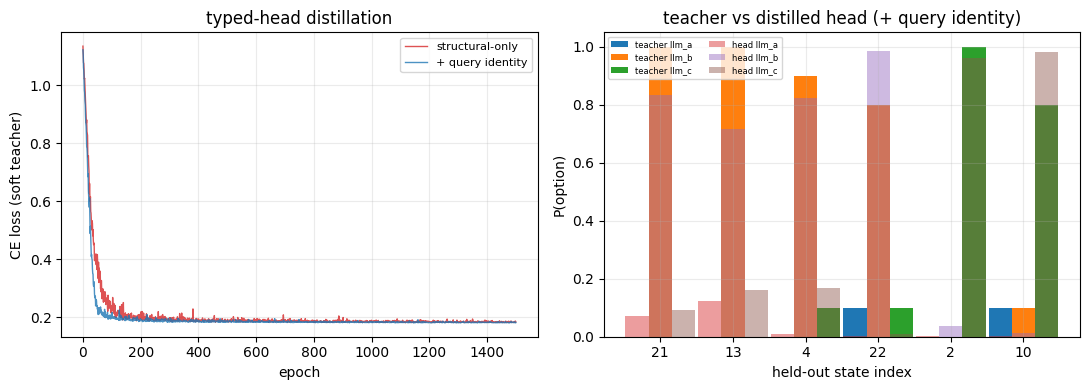

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(losses_s, lw=1.0, alpha=0.8, color="tab:red", label="structural-only")
axes[0].plot(losses_f, lw=1.0, alpha=0.8, color="tab:blue", label="+ query identity")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("CE loss (soft teacher)")
axes[0].set_title("typed-head distillation")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

bar_x = np.arange(len(te_f))
width = 0.32
for j, n in enumerate(OPTION_ORDER):
    axes[1].bar(bar_x + (j - 1) * width, Y[te_f][:, j], width, label=f"teacher {n}")
for j, n in enumerate(OPTION_ORDER):
    axes[1].bar(bar_x + (j - 1) * width, p_f[:, j], width, alpha=0.45, label=f"head {n}")
axes[1].set_xticks(bar_x, [str(i) for i in te_f])
axes[1].set_xlabel("held-out state index")
axes[1].set_ylabel("P(option)")
axes[1].set_title("teacher vs distilled head (+ query identity)")
axes[1].legend(fontsize=6, ncol=2)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/typed_head_distill.png", dpi=110)
plt.show()

## §3 — Plug the recovered student into the loop, then A/B

In [8]:
class TypedHeadRouter(DecisionRouter):
    """The distilled student behind the same DecisionRouter seam."""
    def __init__(self, model, feature_fn, option_order, mu, sd):
        self.model = model
        self.feature_fn = feature_fn
        self.option_order = list(option_order)
        self.mu = mu
        self.sd = sd

    def route(self, state, options, instructions, extra_noul=None):
        x = (self.feature_fn(state) - self.mu) / self.sd
        with torch.no_grad():
            logits = self.model(torch.tensor(x).unsqueeze(0))[0]
        p = torch.softmax(logits, dim=0).numpy()
        probs = {n: float(p[i]) for i, n in enumerate(self.option_order)}
        decision = max(probs, key=probs.get)
        return DecisionRecord(
            decision=decision,
            confidence=float(probs[decision]),
            probabilities=probs,
            decision_type="route_query",
            aux={},
            model="typed-head-distill",
            mock=False,
        )

# deploy the stage-2 student (structural + query identity).
head_router = TypedHeadRouter(
    head_full, lambda s: router_features(s, with_query=True), OPTION_ORDER, mu_f, sd_f
)

head_result = run_jev_loop(
    adapter, head_router, ewm, open_result, QUERIES, WORK, T=8, max_new_tokens=32,
    structural=True, ingest_decision=True,
)
print()
print("typed-head decision distribution:")
for n in adapter.names:
    print(f"  {n:6s} {sum(1 for d in head_result.decision_log if d.decision == n):2d} steps")
print("mean confidence:",
      round(float(np.mean([d.confidence for d in head_result.decision_log])), 4))

torch.save({"model": head_full.state_dict(), "mu": mu_f, "sd": sd_f,
            "option_order": OPTION_ORDER, "feature_dim": X_full.shape[1]},
           f"{WORK}/typed_head.pt")
print("saved:", f"{WORK}/typed_head.pt")

t= 0 q=0  route=llm_c   confidence=0.999  gated=False  mock=False


t= 4 q=4  route=llm_b   confidence=0.775  gated=False  mock=False


t= 7 q=7  route=llm_b   confidence=0.996  gated=False  mock=False

typed-head decision distribution:
  llm_a   0 steps
  llm_b   5 steps
  llm_c   3 steps
mean confidence: 0.9499
saved: /home/alexmy/.cache/ewm-typed-head/typed_head.pt


In [9]:
jev_result = run_jev_loop(
    adapter, jev, ewm, open_result, QUERIES, WORK, T=8, max_new_tokens=32,
    ingest_decision=True,
)

# teacher row comes from the 24-step data-collection run; head and jev run 8.
rows = [("teacher-qwen", teacher_result), ("typed-head", head_result), ("jev-mock", jev_result)]
print(f"{'router':14s} {'choice distribution':30s} {'gated':>6s} {'mean conf':>10s}")
for label, r in rows:
    ds = r.decision_log
    dist = ", ".join(f"{n}:{sum(1 for d in ds if d.decision == n)}" for n in adapter.names)
    print(f"{label:14s} {dist:30s} {sum(r.gated_log):6d} "
          f"{float(np.mean([d.confidence for d in ds])):10.4f}")

t= 0 q=0  route=llm_b   confidence=0.429  gated=False  mock=True


t= 4 q=4  route=llm_c   confidence=0.430  gated=False  mock=True


t= 7 q=7  route=llm_a   confidence=0.427  gated=False  mock=True
router         choice distribution             gated  mean conf
teacher-qwen   llm_a:0, llm_b:17, llm_c:7          0     0.6917
typed-head     llm_a:0, llm_b:5, llm_c:3           0     0.9499
jev-mock       llm_a:3, llm_b:2, llm_c:3           0     0.4312


## Summary

- **Pipeline works end-to-end**: teacher loop with `structural=True` →
  soft-label dataset → tiny MLP distilled with cross-entropy → deployed
  behind the same `DecisionRouter` seam → A/B in the loop. The student
  is a single CPU forward pass on a ≤25-dim vector (no GPU, no API).
- **Structural-only is not enough**: the prompted teacher is degenerate
  (21/24 `llm_c`), so the structural-only head collapses to that prior.
  Adding the **query identity** recovers the teacher's routing — the
  teacher's decisions are driven by the query, not by the lattice.
- **Artifacts**: `distill_dataset.jsonl` (behavioural-cloning dataset),
  `typed_head.pt` (the recovered student).

This is exactly the kind of failure mode a distillation pipeline must
surface. Next steps: (1) a less degenerate teacher (nb17-style prompt
A/B, or temperature sampling to spread the soft labels); (2) more
diverse query banks and longer logs; (3) query/option *text*
embeddings instead of a one-hot; (4) reward fine-tuning of the head
with loop surprise instead of pure distillation; (5) port the head to
a Rust/candle daemon like Laya.